In [115]:
import pandas as pd
import random

In [116]:
L = []
for i in range(10000):
    a = random.randint(1,6)
    b = random.randint(1,6)
    L.append(a+b)

L[:5]


[6, 8, 9, 11, 7]

In [117]:
s = (pd.Series(L).value_counts()/pd.Series(L).value_counts().sum()).sort_index()

<Axes: >

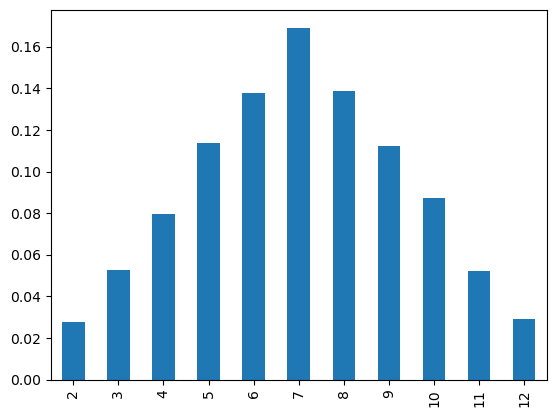

In [118]:
s.plot(kind='bar')

<Axes: >

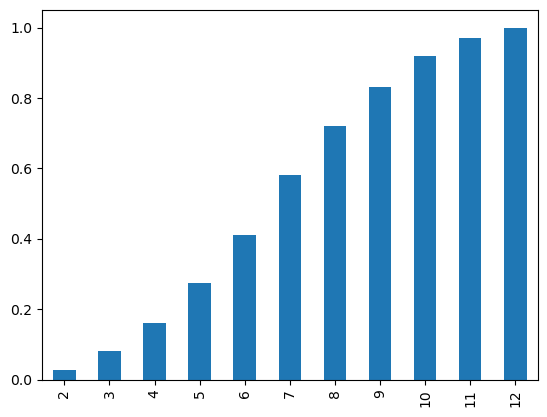

In [119]:
s.cumsum().plot(kind='bar')

In [120]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import normal
sample = normal(loc=50,scale=5,size=1000)

In [121]:
sample_mean =sample.mean()

In [122]:
sample_std = sample.std()

(array([  5.,   9.,  16.,  31.,  38.,  61.,  59.,  87., 100., 105., 112.,
         95., 101.,  67.,  33.,  37.,  15.,  18.,   8.,   3.]),
 array([36.19082335, 37.60737202, 39.0239207 , 40.44046937, 41.85701805,
        43.27356673, 44.6901154 , 46.10666408, 47.52321275, 48.93976143,
        50.35631011, 51.77285878, 53.18940746, 54.60595613, 56.02250481,
        57.43905349, 58.85560216, 60.27215084, 61.68869951, 63.10524819,
        64.52179687]),
 <BarContainer object of 20 artists>)

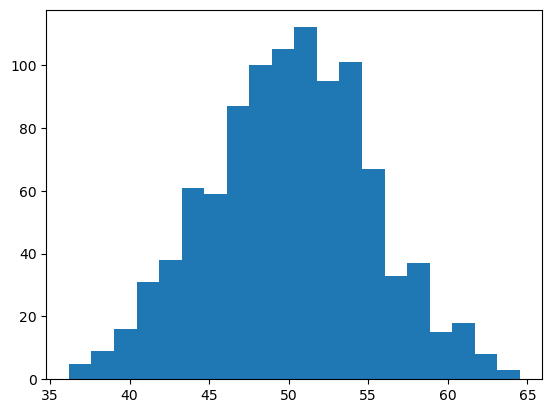

In [123]:
plt.hist(sample,bins=20)

In [124]:
#fit the distribution with the above parameters
from scipy.stats import norm
dist = norm(sample_mean,sample_std)

In [125]:
values = np.linspace(sample.min(),sample.max(),1000)

In [126]:
probabilities = [dist.pdf(x) for x in values]

(array([0.00352971, 0.00635347, 0.01129506, 0.02188418, 0.02682576,
        0.04306241, 0.04165053, 0.06141688, 0.07059411, 0.07412382,
        0.07906541, 0.06706441, 0.07130006, 0.04729806, 0.02329606,
        0.02611982, 0.01058912, 0.01270694, 0.00564753, 0.00211782]),
 array([36.19082335, 37.60737202, 39.0239207 , 40.44046937, 41.85701805,
        43.27356673, 44.6901154 , 46.10666408, 47.52321275, 48.93976143,
        50.35631011, 51.77285878, 53.18940746, 54.60595613, 56.02250481,
        57.43905349, 58.85560216, 60.27215084, 61.68869951, 63.10524819,
        64.52179687]),
 <BarContainer object of 20 artists>)

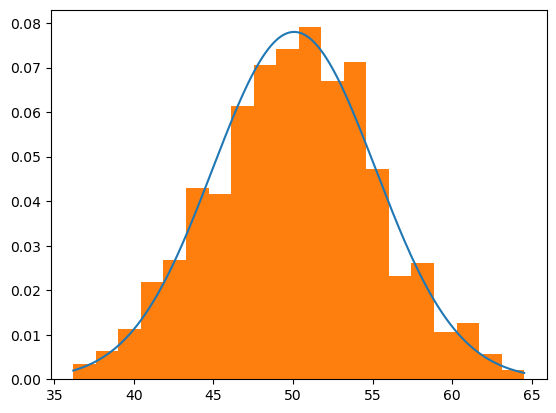

In [127]:
plt.plot(values,probabilities)
plt.hist(sample,bins=20,density=True)

/var/folders/gm/nbsrp6ks1gnb1c4z3v9rvb4r0000gn/T/ipykernel_38369/2262056078.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sample)


<Axes: ylabel='Density'>

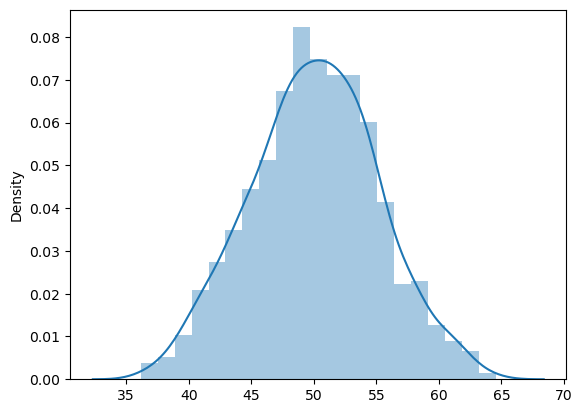

In [128]:
#sns.dist also does the same work
import seaborn as sns
sns.distplot(sample)

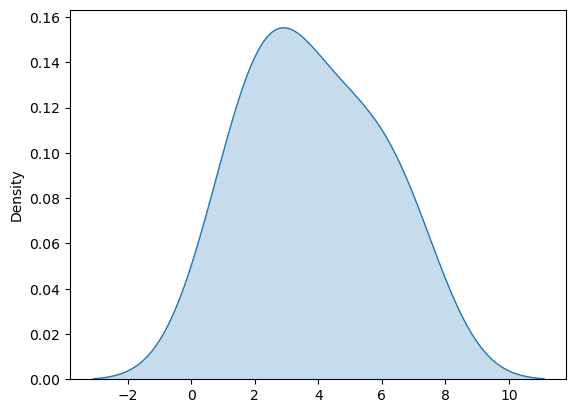

In [129]:
data = [1, 2, 2.5, 3, 4, 5, 6, 7]
sns.kdeplot(data, fill=True)
plt.show()

# KDE

In [130]:
sample1 = normal(loc=20,scale=5,size=300)
sample2 = normal(loc=40,scale=5,size=700)
sampleX = np.hstack((sample1,sample2))

(array([ 4.,  2.,  2.,  3.,  6.,  8.,  2., 15., 16., 27., 29., 32., 33.,
        28., 29., 13., 15., 11., 13., 14., 11., 22., 22., 29., 55., 64.,
        65., 49., 71., 75., 61., 49., 34., 35., 17., 16., 11.,  4.,  6.,
         2.]),
 array([ 5.6266341 ,  6.84243996,  8.05824582,  9.27405167, 10.48985753,
        11.70566338, 12.92146924, 14.1372751 , 15.35308095, 16.56888681,
        17.78469266, 19.00049852, 20.21630438, 21.43211023, 22.64791609,
        23.86372194, 25.0795278 , 26.29533365, 27.51113951, 28.72694537,
        29.94275122, 31.15855708, 32.37436293, 33.59016879, 34.80597465,
        36.0217805 , 37.23758636, 38.45339221, 39.66919807, 40.88500393,
        42.10080978, 43.31661564, 44.53242149, 45.74822735, 46.96403321,
        48.17983906, 49.39564492, 50.61145077, 51.82725663, 53.04306249,
        54.25886834]),
 <BarContainer object of 40 artists>)

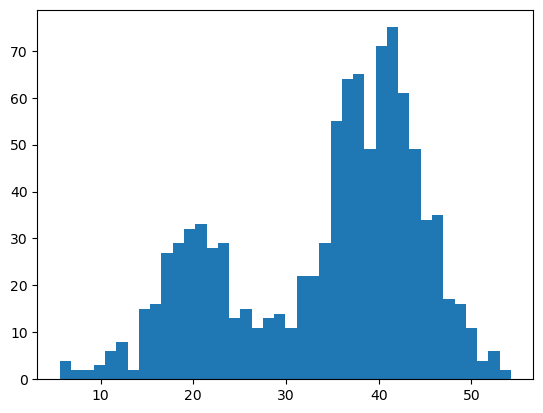

In [131]:
plt.hist(sampleX,bins=40)

In [132]:
from sklearn.neighbors import KernelDensity
kde = KernelDensity(kernel='gaussian', bandwidth=3)

In [133]:
sampleX = sampleX.reshape(len(sampleX),1)
kde.fit(sampleX)


KernelDensity(bandwidth=3)

In [134]:
values_1 = np.linspace(sampleX.min(),sampleX.max(),1000)
values_1 = values_1.reshape(len(values_1),1)

In [135]:
probabilities = kde.score_samples(values_1)
probabilities = np.exp(probabilities)
#The .score_samples() method is commonly used in scikit-learn models (especially in density estimation models) to return the log of the probability density function (log PDF) evaluated at given samples.
#thats why we use exponential function to cancel it out

<Axes: ylabel='Density'>

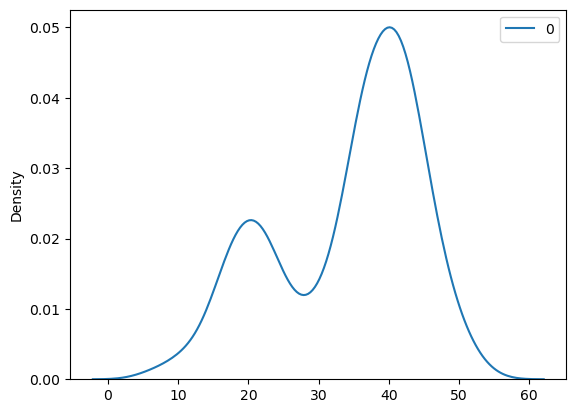

In [136]:
import seaborn as sns
sns.kdeplot(sampleX)


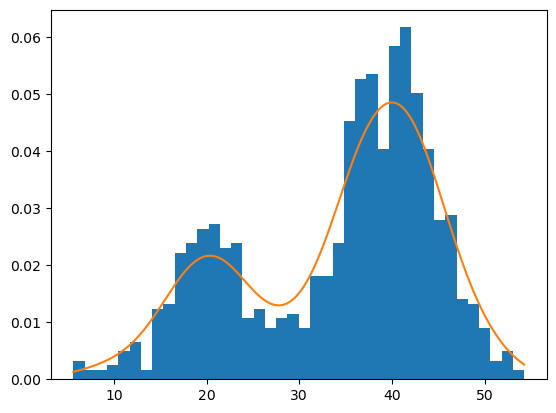

In [137]:
plt.hist(sampleX,bins=40,density=True)
plt.plot(values_1,probabilities)

# 2 D plot

In [138]:
df = sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


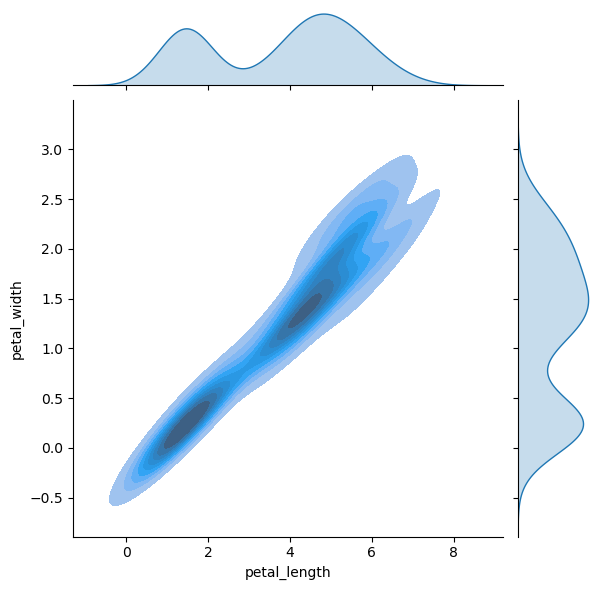

In [139]:
sns.jointplot(x='petal_length',y='petal_width',data=df,kind='kde',fill=True)

In [140]:
iris = sns.load_dataset('iris')

# QQ PLOT

In [141]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Density'>

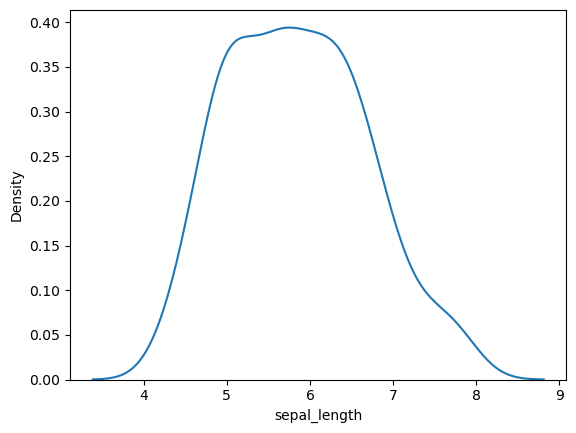

In [142]:
sns.kdeplot(iris['sepal_length'])

In [143]:
temp = sorted(iris['sepal_length'].to_list())

In [144]:
y_quant = []
for i in range(1,101):
    y_quant.append(np.percentile(temp,i))

In [145]:
samples = np.random.normal(loc=0,scale=1,size=1000)


In [146]:
x_quant = []
for i in range(1,101):
    x_quant.append(np.percentile(samples,i))

<Axes: >

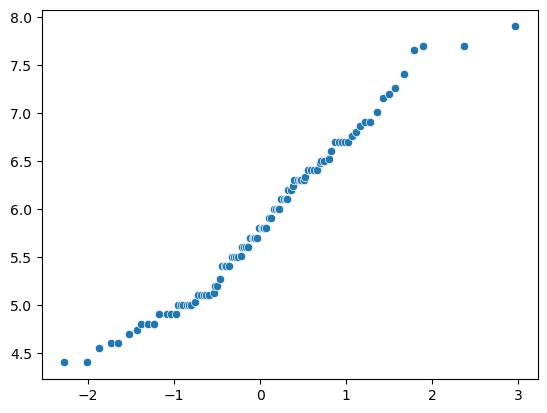

In [147]:
sns.scatterplot(x=x_quant,y=y_quant)

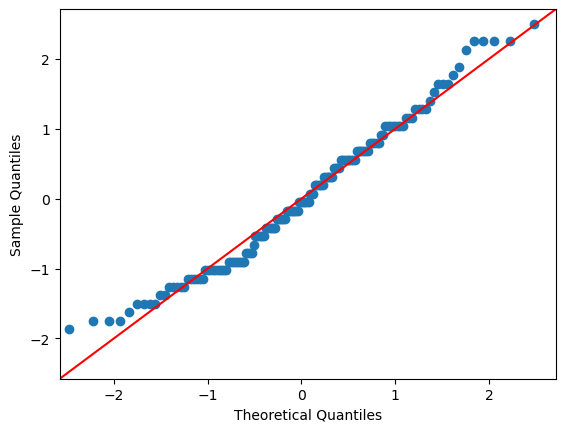

In [148]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig = sm.qqplot(iris['sepal_length'],line='45',fit=True)
plt.show()


# Pareto Distribution

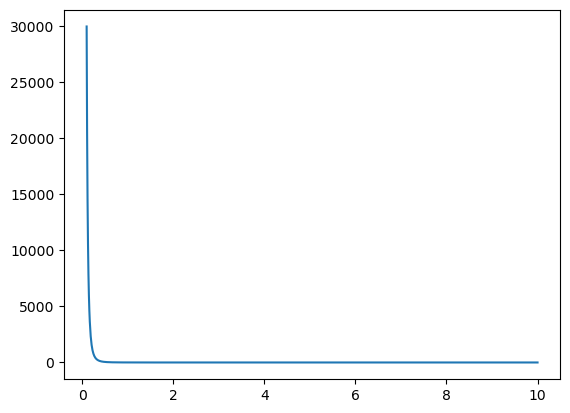

In [149]:
import numpy as np 
import matplotlib.pyplot as plt
#define the parameters for pareto distribution
alpha = 3
xm = 1

#create an array of x values
x = np.linspace(0.1,10,1000)

#calculate the pdf
y = alpha * (xm**alpha) / (x**(alpha+1))
#plot the pdf
plt.plot(x,y)
plt.show()



if the log graph is a straight line then it is supposed to be a pareto 

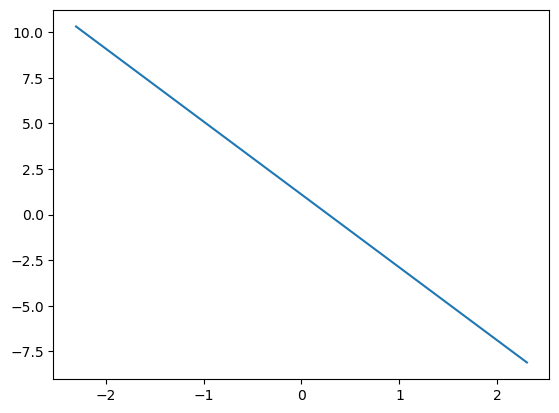

In [150]:
plt.plot(np.log(x),np.log(y))
plt.show()

# ploting a qq plot


In [151]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats


In [152]:
# Example: Normal data
data = np.random.normal(loc=0, scale=1, size=1000)


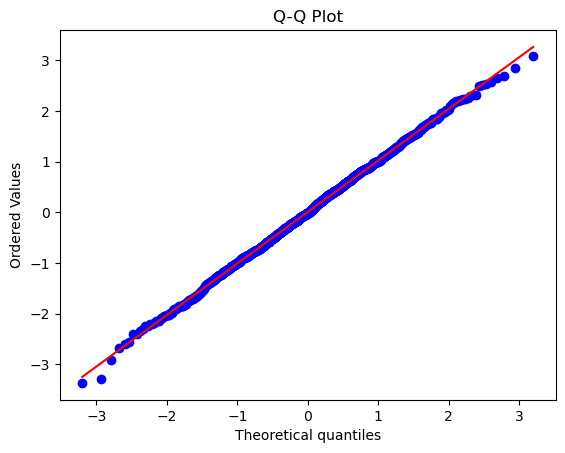

In [153]:
stats.probplot(data, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()
